In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from PIL import Image

In [ ]:
def pixel_arith_op(a, b, op, min_val=0, max_val=255):
    ops = {
        '+': lambda x, y: x + y,
        '-': lambda x, y: x - y,
        '*': lambda x, y: x * y,
        '/': lambda x, y: x / y if y != 0 else float('inf'),
    }
    result = ops[op](a, b)

    # float -> int 
    if isinstance(result, float):
        result = round(result)

    # boundary check
    if min_val is not None and result < min_val:
        result = min_val
    if max_val is not None and result > max_val:
        result = max_val

    # infinity check
    if math.isinf(result) or math.isnan(result):
        result = 0

    return result

def img_arith_op(arr_a, arr_b, op):
    if arr_a.shape != arr_b.shape: # check shape
        return None
    
    a = arr_a.astype(float)
    b = arr_b.astype(float)
    result = np.zeros_like(a, dtype=float)

    for idx in np.ndindex(a.shape):
        result[idx] = pixel_arith_op(a[idx], b[idx], op, min_val=0, max_val=255)
 
    return result.astype(np.uint8)

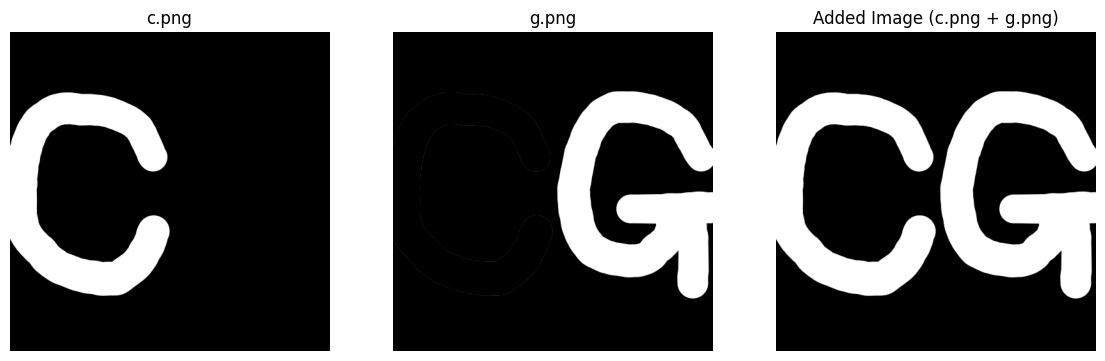

In [50]:
# image path
C_PATH = 'c.png'
G_PATH = 'g.png'

# load image
c  = np.array(Image.open(C_PATH).convert("L"))
g  = np.array(Image.open(G_PATH).convert("L"))
added_image = img_arith_op(c, g, '+') # add operation

fig, axes = plt.subplots(1, 3, figsize=(14, 9))
axes[0].imshow(c, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(C_PATH, fontsize=12)
axes[0].axis('off')

axes[1].imshow(g, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(G_PATH, fontsize=12)
axes[1].axis('off')

axes[2].imshow(added_image, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Added Image (c.png + g.png)', fontsize=12)
axes[2].axis('off')

plt.show()

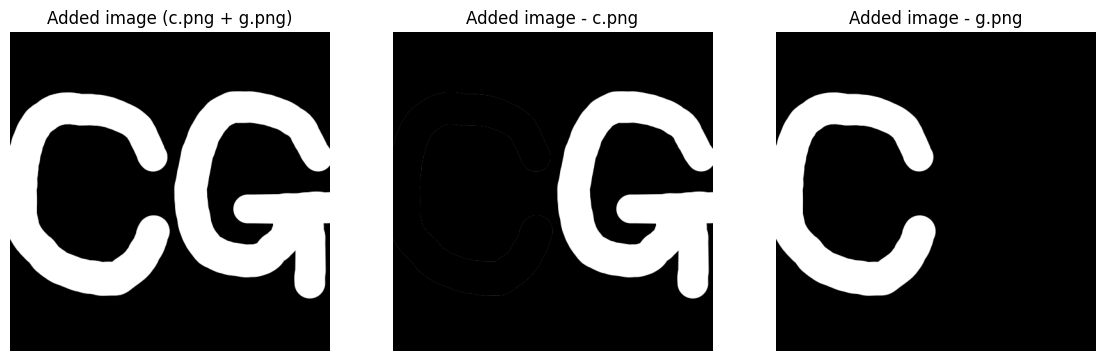

In [51]:
# minus operation (usiung added image and c.png, g.png)
minus_c = img_arith_op(added_image, c, '-')
minus_g = img_arith_op(added_image, g, '-')

fig, axes = plt.subplots(1, 3, figsize=(14, 9))
axes[0].imshow(added_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Added image (c.png + g.png)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(minus_c, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Added image - c.png', fontsize=12)
axes[1].axis('off')

axes[2].imshow(minus_g, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Added image - g.png', fontsize=12)
axes[2].axis('off')

plt.show()

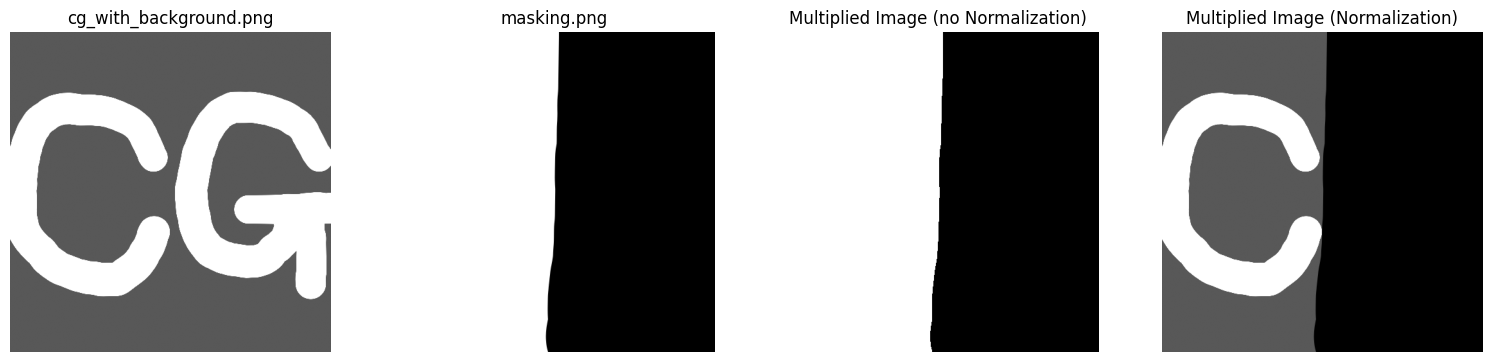

In [52]:
cg_bg   = np.array(Image.open("cg_with_background.png").convert("L"))
masking = np.array(Image.open("masking.png").convert("L"))
# masking image preprocessing
# normally multiply does not require normalization,
# but i want to apply masking, i convert pixel values from 0~255 to 0~1
masking_01 = (masking / 255).astype(float)

# multiply operation
multiplied_image = img_arith_op(cg_bg, masking, '*')
masked_image = img_arith_op(cg_bg, masking_01, '*')

fig, axes = plt.subplots(1, 4, figsize=(19, 9))
axes[0].imshow(cg_bg, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('cg_with_background.png', fontsize=12)
axes[0].axis('off')

axes[1].imshow(masking, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('masking.png', fontsize=12)
axes[1].axis('off')

axes[2].imshow(multiplied_image, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Multiplied Image (no Normalization)', fontsize=12)
axes[2].axis('off')

axes[3].imshow(masked_image, cmap='gray', vmin=0, vmax=255)
axes[3].set_title('Multiplied Image (Normalization)', fontsize=12)
axes[3].axis('off')

plt.show()

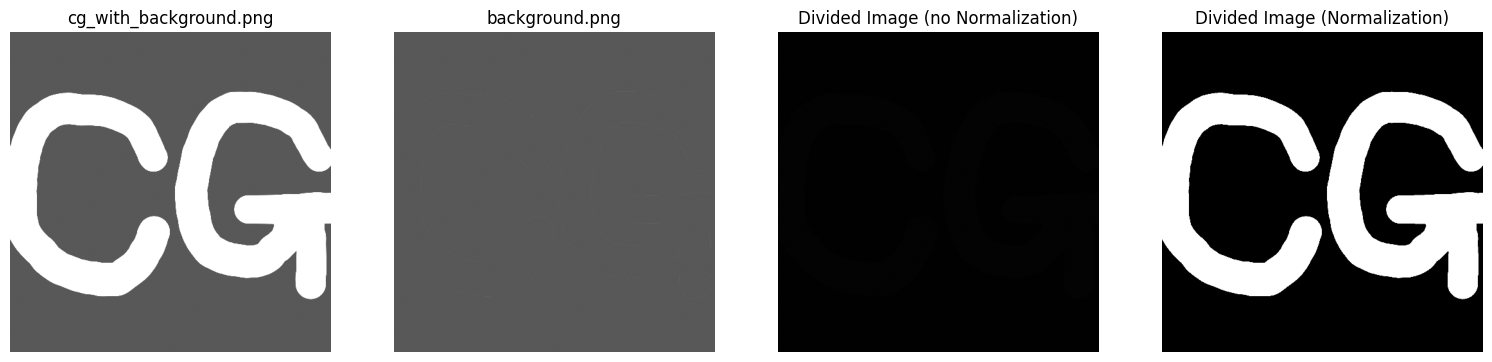

In [ ]:
cg_bg = np.array(Image.open("cg_with_background.png").convert("L"))
bg = np.array(Image.open("background.png").convert("L"))
 
divided_image = img_arith_op(cg_bg, bg, '/')

# without normalization: divided values are in range 0~5, so the image appears almost black
# with normalization: rescale to 0~255 to make the result visible
divided_norm = divided_image.astype(float)
divided_norm = (divided_norm - divided_norm.min()) / (divided_norm.max() - divided_norm.min()) * 255
divided_norm = divided_norm.astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(19, 9))
axes[0].imshow(cg_bg, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('cg_with_background.png', fontsize=12)
axes[0].axis('off')

axes[1].imshow(bg, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('background.png', fontsize=12)
axes[1].axis('off')

axes[2].imshow(divided_image, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Divided Image (no Normalization)', fontsize=12)
axes[2].axis('off')

axes[3].imshow(divided_norm, cmap='gray', vmin=0, vmax=255)
axes[3].set_title('Divided Image (Normalization)', fontsize=12)
axes[3].axis('off')

plt.show()